# Exercise 1

This notebook follows Problem 1 of the exam brief: exact diagonalization, subsystem partitions, and exact entanglement probes for a small open TFIM chain. It compares the ferromagnetic, critical, and paramagnetic points on the same numerical footing so the report stays centered on the exact small-system benchmark.


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nqs.observables as observables
from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import build_system, exact_observables_summary, half_subsystem

In [3]:
chain_length = 16
subsystem_sites = half_subsystem(chain_length)
subsystem_B_sites = tuple(site for site in range(chain_length) if site not in subsystem_sites)
alternating_chain_state = np.resize(np.array([0, 1], dtype=np.uint8), chain_length)
exercise_output_dir = ensure_report_output_dir('exercise_1')

phase_specs = {
    'ferromagnetic_g0.5': {'g': 0.5, 'phase': 'Ferromagnetic ordered phase (g = 0.5)'},
    'critical_g1.0': {'g': 1.0, 'phase': 'Critical point (g = 1.0)'},
    'paramagnetic_g1.5': {'g': 1.5, 'phase': 'Paramagnetic disordered phase (g = 1.5)'},
}

g_values = {label: spec['g'] for label, spec in phase_specs.items()}
phase_labels = {label: spec['phase'] for label, spec in phase_specs.items()}

exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_1')

## 1/a Exact Diagonalization Setup And Basis Partition

Problem 1 asks for ground-state entanglement diagnostics, but the short product-state table below serves a different purpose: it fixes the computational-basis ordering and the $A|B$ partition before any ground-state data are interpreted. That makes the later reduced-density-matrix and SWAP calculations easier to read, because every entropy value is tied back to the same explicit bit ordering.

For the open chain with $L = 16$ spin-$1/2$ sites, the exact-diagonalization Hilbert space has dimension $2^{16} = 65{,}536$. We use the computational basis $|s_0 s_1 \ldots s_{15}\rangle$ with $s_i \in \{0,1\}$, and the backend stores site $0$ as the least-significant bit so that the basis index is $n = \sum_{i=0}^{15} s_i 2^i$. The table lists three representative product states in that basis: the all-down state, the all-up state, and an alternating chain pattern.

The benchmark uses the half-chain cut $A = (0,1,\ldots,7)$ and $B = (8,9,\ldots,15)$. In that ordering, the statevector reshapes into a matrix of amplitudes $\psi_{ab}$ with shape $2^{|A|} \times 2^{|B|} = 256 \times 256$. That reshaping is the starting point for reduced density matrices, Schmidt values, and all exact entanglement diagnostics used in the rest of the notebook.

In [4]:
exercise_1_systems = {
    label: build_system(
        lattice_shape=(chain_length, 1),
        pbc=False,
        hamiltonian='tfim',
        J=1.0,
        h=g_value,
    )
    for label, g_value in g_values.items()
}

reference_hilbert = next(iter(exercise_1_systems.values()))['hilbert']
product_states = {
    'all_zeros': np.zeros(chain_length, dtype=np.uint8),
    'all_ones': np.ones(chain_length, dtype=np.uint8),
    'alternating_chain': alternating_chain_state.copy(),
}

partition_table = pd.DataFrame([
    {
        'chain_length': chain_length,
        'subsystem_A': subsystem_sites,
        'subsystem_B': subsystem_B_sites,
        'basis_state': name,
        'state_bits': ''.join(str(int(bit)) for bit in state),
        'basis_index': reference_hilbert.state_to_index(state),
    }
    for name, state in product_states.items()
])
partition_table

,chain_length,subsystem_A,subsystem_B,basis_state,state_bits,basis_index
0,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",all_zeros,0000000000000000,0
1,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",all_ones,1111111111111111,65535
2,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",alternating_chain,0101010101010101,43690


Caption: the product-state table fixes the exact basis ordering and the $8|8$ cut used throughout the notebook. Interpretation: it is a basis-and-partition reference, not part of the ground-state search itself.

## 1/b Von Neumann Entropy And The Reduced Density Matrix

For an exact statevector we can form the reduced density matrix $\rho_A = \mathrm{tr}_B |\psi\rangle\langle\psi|$ and evaluate

$$S_1(A) = -\mathrm{tr}(\rho_A \log \rho_A).$$

The eigenvalues of $\rho_A$ are the squares of the Schmidt singular values across the bipartition. In matrix-product-state language, they are the bond singular values across the cut, so they show how much weight each Schmidt sector carries. A rapidly decaying spectrum is easy to compress, while a broad spectrum signals stronger entanglement and a larger bond-dimension requirement.

The exact-diagonalization tables below compare the $L = 16$ ferromagnetic, critical, and paramagnetic benchmarks on the same half-chain cut. The main numerical takeaway is simple: the critical point carries the broadest entanglement, while the two off-critical reference points remain more weakly entangled on this finite chain. Von Neumann entropy is exact and straightforward at this size, but for a neural quantum state it is not generally efficient because one would need the full reduced density matrix, not just sampled expectation values.

In [5]:
exercise_1_exact = {label: exact_observables_summary(system['operator'], subsystem=subsystem_sites) for label, system in exercise_1_systems.items()}

exercise_1_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'ground_energy': exact['ground_energy'],
        'half_partition_von_neumann': exact['half_partition_von_neumann'],
        'half_partition_renyi2': exact['half_partition_renyi2'],
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_spectrum_table = pd.concat([
    pd.DataFrame({
        'phase': phase_labels[label],
        'g': g_values[label],
        'level': np.arange(1, spectrum.size + 1),
        'lambda': spectrum,
    })
    for label, exact in exercise_1_exact.items()
    for spectrum in [observables.entanglement_spectrum(exact['ground_state'], subsystem_sites, n_levels=8)]
], ignore_index=True)

exercise_1_summary

,phase,g,ground_energy,half_partition_von_neumann,half_partition_renyi2
0,Ferromagnetic ordered phase (g = 0.5),0.5,-16.146051,0.696037,0.693736
1,Critical point (g = 1.0),1.0,-20.016388,0.423409,0.284540
2,Paramagnetic disordered phase (g = 1.5),1.5,-26.566812,0.153473,0.070774


Caption: the exact summary table reports the ground energy and both half-chain entropies for the three TFIM reference points on equal footing. Interpretation: the critical row should show the largest entropies, while the off-critical rows provide the lower-entanglement comparison cases.

## 1/c Renyi-2 And The SWAP-Operator Identity

For $\alpha = 2$, the Renyi entropy is

$$S_2(A) = -\log\mathrm{tr}(\rho_A^2).$$

The quantity $\mathrm{tr}(\rho_A^2)$ is the purity. It has two extremal limits that are useful as checks: for a pure product state across the cut, $\rho_A$ is itself pure and $\mathrm{tr}(\rho_A^2)=1$, so $S_2(A)=0$; for a maximally mixed reduced density matrix on a subsystem of dimension $d_A$, $\mathrm{tr}(\rho_A^2)=1/d_A$, so $S_2(A)=\log d_A$.

The SWAP identity used later for neural quantum states is derived by writing the reduced density matrix in the computational basis and tracing over $B$. For $\rho = |\psi\rangle\langle\psi|$ with amplitudes $\psi_{ab}$,

$$\mathrm{tr}(\rho_A^2) = \sum_{a,a',b,b'} \psi_{ab} \psi^*_{a'b} \psi_{a'b'} \psi^*_{ab'} = \langle \psi \otimes \psi | \mathrm{SWAP}_A | \psi \otimes \psi \rangle,$$

where $\mathrm{SWAP}_A$ exchanges only the subsystem-$A$ degrees of freedom between two replicas and leaves $B$ untouched. In plain language, the estimator checks whether two sampled copies of the state still agree after the $A$ part is swapped. More generally, $\mathrm{tr}(\rho_A^\alpha) = \langle \psi^{\otimes \alpha} | \mathrm{SWAP}_A^{(\alpha)} | \psi^{\otimes \alpha} \rangle$ uses a cyclic permutation of $\alpha$ replicas, but each extra replica makes the estimator more expensive and noisier.

Direct access to the full $\rho_A$ or to all of its eigenvalues is not efficient for a neural quantum state in general because $\rho_A$ has dimension $2^{|A|} \times 2^{|A|}$, so reconstructing it requires exponentially many amplitudes or matrix elements. On a sampled ansatz one can estimate low-order traces such as $\mathrm{tr}(\rho_A^2)$, but not routinely reconstruct the entire spectrum for anything beyond tiny systems.


In [6]:
exercise_1_swap_identity = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'purity_from_trace_rho2': float(np.trace(rho @ rho).real),
        'purity_from_exp_minus_S2': float(np.exp(-exact['half_partition_renyi2'])),
    }
    for label, exact in exercise_1_exact.items()
    for rho in [observables.reduced_density_matrix(exact['ground_state'], subsystem_sites)]
]).sort_values('g').reset_index(drop=True)

exercise_1_swap_identity

,phase,g,purity_from_trace_rho2,purity_from_exp_minus_S2
0,Ferromagnetic ordered phase (g = 0.5),0.5,0.499706,0.499706
1,Critical point (g = 1.0),1.0,0.752360,0.752360
2,Paramagnetic disordered phase (g = 1.5),1.5,0.931673,0.931673


Caption: the SWAP purity check matches the direct trace evaluation for every phase. Interpretation: this exact agreement validates the Renyi-2 identity that is later reused for sampled neural-quantum-state estimators.

## 1/d Interpreting $S_1$ And $S_2$

For gapped one-dimensional ground states, the entanglement follows an area law: $S_1(A)$ and $S_2(A)$ stay $O(1)$ across a fixed boundary cut instead of growing proportionally to $|A|$. A volume-law state is the opposite extreme, with entropy that scales linearly with $|A|$. Long-range entanglement is different again: it is not just large entropy, but entropy structure that cannot be reduced to a short-range boundary contribution alone.

The tail of the entanglement spectrum matters more for $S_1$ than for $S_2$. Von Neumann entropy weights every nonzero Schmidt value through $-\lambda \log \lambda$, so tiny Schmidt coefficients still contribute. Renyi-2 emphasizes the larger Schmidt values through $\sum_i \lambda_i^2$, which makes it less sensitive to the smallest part of the spectrum. That difference is why $S_1$ reacts more strongly to weak long tails in the spectrum, while $S_2$ is the more compact summary of the dominant Schmidt sectors.


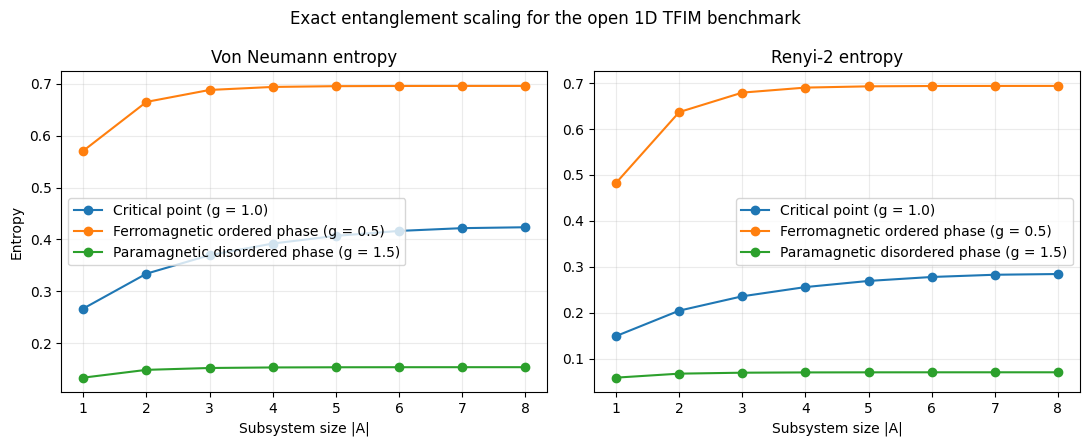

In [7]:
exercise_1_entropy_scan = pd.concat([
    exact['entropy_table'].assign(phase=phase_labels[label], g=g_values[label])
    for label, exact in exercise_1_exact.items()
], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
for phase, group in exercise_1_entropy_scan.groupby('phase'):
    ordered = group.sort_values('subsystem_size')
    axes[0].plot(ordered['subsystem_size'], ordered['von_neumann'], marker='o', label=phase)
    axes[1].plot(ordered['subsystem_size'], ordered['renyi2'], marker='o', label=phase)

axes[0].set_title('Von Neumann entropy')
axes[1].set_title('Renyi-2 entropy')
for axis in axes:
    axis.set_xlabel('Subsystem size |A|')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Entropy')
axes[0].legend()
axes[1].legend()
figure.suptitle('Exact entanglement scaling for the open 1D TFIM benchmark')
figure.tight_layout()

Caption: the entanglement-scaling plot tracks $S_1$ and $S_2$ versus subsystem size on the same $L = 16$ open chain. Interpretation: the critical curve stays broader across subsystem sizes, while the ferromagnetic and paramagnetic curves flatten sooner on this finite benchmark.

In [8]:
exercise_1_scaling_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'heuristic_log_fit_slope_S2': exact['scaling_fit']['slope'] if exact['scaling_fit'] is not None else np.nan,
        'heuristic_log_fit_r2_S2': exact['scaling_fit']['r_squared'] if exact['scaling_fit'] is not None else np.nan,
        'finite_size_reading': 'Off-critical ordered reference' if np.isclose(g_values[label], 0.5) else ('Critical reference point' if np.isclose(g_values[label], 1.0) else 'Off-critical disordered reference'),
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_scaling_summary

,phase,g,heuristic_log_fit_slope_S2,heuristic_log_fit_r2_S2,finite_size_reading
0,Ferromagnetic ordered phase (g = 0.5),0.5,0.091916,0.777056,Off-critical ordered reference
1,Critical point (g = 1.0),1.0,0.066499,0.980511,Critical reference point
2,Paramagnetic disordered phase (g = 1.5),1.5,0.005032,0.773604,Off-critical disordered reference


Caption: the heuristic log-fit summary is a finite-size diagnostic for the $L = 16$ benchmark, not an asymptotic scaling claim. Interpretation: it compactly shows that the critical point is the most consistent with enhanced logarithmic growth across the accessible subsystem sizes.

## Final Conclusions

Exact diagonalization on the open $L = 16$ TFIM chain gives a compact report-quality answer to Problem 1. The ferromagnetic, critical, and paramagnetic points are compared on the same footing, and the fixed half-chain partition makes the $A|B$ reshaping explicit before any entropy values are interpreted. The eigenvalues of $\rho_A$ are the squared Schmidt coefficients, so they are the entanglement data that an MPS would compress into bond singular values.

For this exact benchmark, $S_1$ is evaluated directly from $\rho_A$, while $S_2$ follows from the SWAP identity and is the more practical observable for a sampled neural quantum state. The numerical tables and the subsystem scan both show the same finite-size picture: the critical point has the broadest entanglement, while the ferromagnetic and paramagnetic references saturate more quickly. The final log-fit table should therefore be read only as a heuristic finite-size summary consistent with that trend, not as an asymptotic proof.

## Export Exercise 1 Artifacts

Persist the exact summary, the SWAP check, the scaling table, and the entanglement-scaling figure for later report assembly.

In [9]:
summary_paths = save_report_table(exercise_1_summary, 'exercise_1_exact_summary', output_dir=exercise_output_dir)
spectrum_paths = save_report_table(exercise_1_spectrum_table, 'exercise_1_entanglement_spectrum', output_dir=exercise_output_dir)
swap_paths = save_report_table(exercise_1_swap_identity, 'exercise_1_swap_identity', output_dir=exercise_output_dir)
scaling_paths = save_report_table(exercise_1_scaling_summary, 'exercise_1_scaling_summary', output_dir=exercise_output_dir)
figure_path = save_report_figure(figure, 'exercise_1_entropy_scaling', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_1', 'name': 'exercise_1_exact_summary', 'path': str(summary_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_entanglement_spectrum', 'path': str(spectrum_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_swap_identity', 'path': str(swap_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_scaling_summary', 'path': str(scaling_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_entropy_scaling', 'path': str(figure_path)},
])

,section,name,path
0,exercise_1,exercise_1_entanglement_spectrum,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_1,exercise_1_entropy_scaling,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_1,exercise_1_exact_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_1,exercise_1_scaling_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_1,exercise_1_swap_identity,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
